In [34]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

In [35]:
sleep = [p for p in prices['product'].unique() if str(p).startswith("SLEEP")]

In [36]:
prices = prices[prices["product"].isin(sleep)].copy()
prices.tail(5)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1499962,4,2999900,SLEEP_POD_COTTON,11409,13,11407,15,,,11419,13,11420,15,,,11414.0,0.0
1499975,4,2999900,SLEEP_POD_NYLON,10730,13,10729,15,,,10739,13,10740,15,,,10734.5,0.0
1499981,4,2999900,SLEEP_POD_LAMB_WOOL,10803,13,10802,15,,,10813,13,10814,15,,,10808.0,0.0
1499983,4,2999900,SLEEP_POD_SUEDE,11795,13,11794,15,,,11806,13,11807,15,,,11800.5,0.0
1499988,4,2999900,SLEEP_POD_POLYESTER,11964,13,11963,15,,,11975,13,11976,15,,,11969.5,0.0


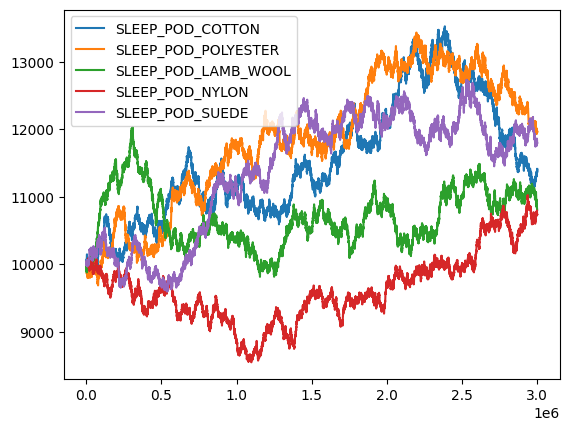

In [37]:
for p in sleep:
    subset = prices[prices['product'] == p]
    plt.plot(subset['timestamp'], subset['mid_price'], label=p)
plt.legend()
plt.show()

In [38]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

In [39]:

# 10-tick block returns (1 tick = 100 ts → block = 1000 ts)
BLOCK_TS = 1000
sleep_cols = [c for c in mids.columns if c.startswith("SLEEP_POD")]
filled = mids[sleep_cols].ffill()
blocked = filled.groupby(filled.index // BLOCK_TS).last()
returns = blocked.pct_change().dropna()

short = {c: c.replace("SLEEP_POD_", "") for c in sleep_cols}

print("10-tick block returns shape:", returns.shape)
returns.rename(columns=short).describe().round(5)


10-tick block returns shape: (2999, 5)


product,COTTON,LAMB_WOOL,NYLON,POLYESTER,SUEDE
count,2999.00000,2999.00000,2999.00000,2999.00000,2999.00000
mean,0.00005,0.00003,0.00003,0.00006,0.00006
std,0.00316,0.00326,0.00319,0.00320,0.00312
min,-0.01146,-0.01074,-0.01245,-0.01109,-0.01133
25%,-0.00210,-0.00209,-0.00216,-0.00209,-0.00207
50%,0.00005,0.00000,-0.00005,0.00000,0.00009
75%,0.00230,0.00221,0.00220,0.00224,0.00224
max,0.00955,0.01148,0.01195,0.01074,0.00994


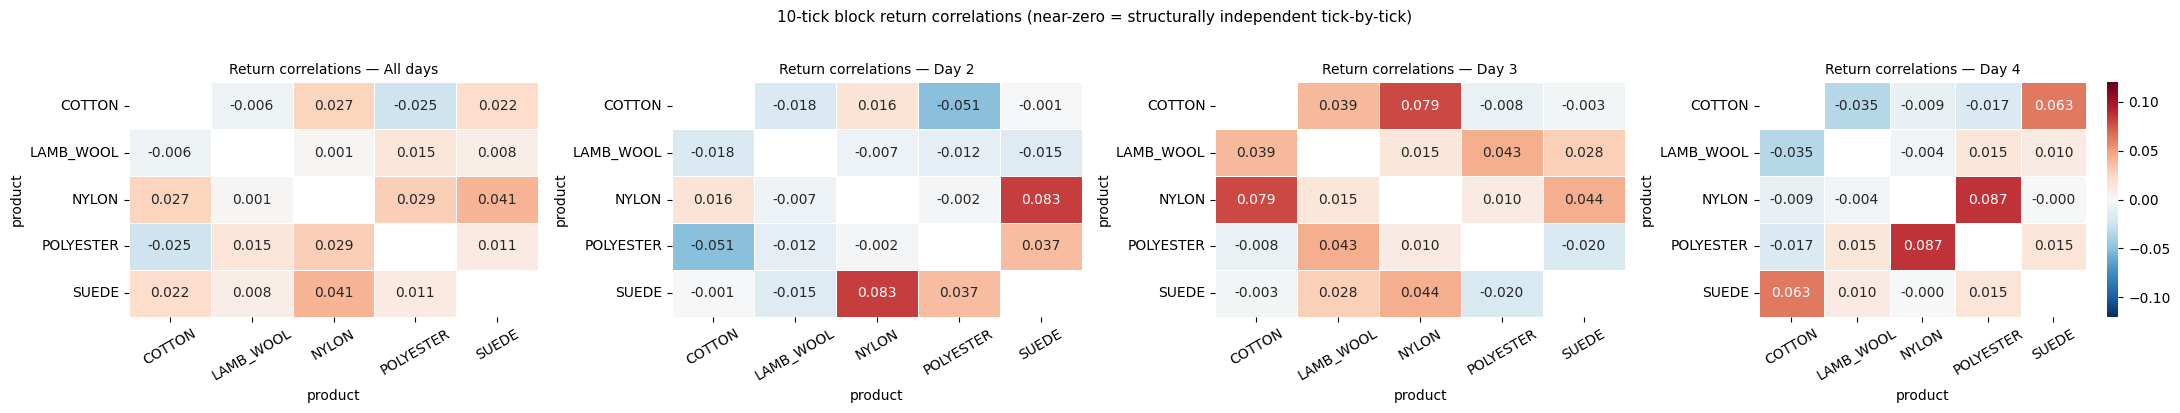

Full-sample pairwise return correlations:
  COTTON       vs LAMB_WOOL   : -0.0062
  COTTON       vs NYLON       : +0.0270
  COTTON       vs POLYESTER   : -0.0252
  COTTON       vs SUEDE       : +0.0217
  LAMB_WOOL    vs NYLON       : +0.0011
  LAMB_WOOL    vs POLYESTER   : +0.0153
  LAMB_WOOL    vs SUEDE       : +0.0082
  NYLON        vs POLYESTER   : +0.0292
  NYLON        vs SUEDE       : +0.0412
  POLYESTER    vs SUEDE       : +0.0112


In [40]:

# ── Return correlation heatmap ────────────────────────────────────────────────
import seaborn as sns

corr = returns.corr().rename(columns=short, index=short)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

DAY_BOUNDS = [(0, 1_000_000), (1_000_000, 2_000_000), (2_000_000, 3_000_000)]
titles = ["All days", "Day 2", "Day 3", "Day 4"]

datasets = [returns] + [
    returns[(returns.index * BLOCK_TS >= lo) & (returns.index * BLOCK_TS < hi)]
    for lo, hi in DAY_BOUNDS
]

vmax = 0.12
for ax, data, title in zip(axes, datasets, titles):
    c = data.corr().rename(columns=short, index=short)
    mask = np.eye(len(c), dtype=bool)
    sns.heatmap(c, ax=ax, annot=True, fmt=".3f", cmap="RdBu_r",
                center=0, vmin=-vmax, vmax=vmax, mask=mask,
                linewidths=0.5, cbar=(ax == axes[-1]))
    ax.set_title(f"Return correlations — {title}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("10-tick block return correlations (near-zero = structurally independent tick-by-tick)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

print("Full-sample pairwise return correlations:")
from itertools import combinations
for a, b in combinations(sleep_cols, 2):
    print(f"  {short[a]:12s} vs {short[b]:12s}: {corr.loc[short[a], short[b]]:+.4f}")


In [41]:

# ── Granger causality on 10-tick block returns ────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests
from itertools import permutations
import warnings
warnings.filterwarnings("ignore")

MAXLAG = 10
sig_results = []

for a, b in permutations(sleep_cols, 2):
    data = returns[[b, a]].dropna()
    res  = grangercausalitytests(data, maxlag=MAXLAG, verbose=False)
    ps   = {lag: res[lag][0]["ssr_ftest"][1] for lag in range(1, MAXLAG + 1)}
    best = min(ps, key=ps.get)
    if ps[best] < 0.05:
        sig_results.append((a, b, ps[best], best))

sig_results.sort(key=lambda x: x[2])

print("Significant Granger causality (p < 0.05):\n")
print(f"  {'Leader':12s}  →  {'Follower':12s}   p-value   lag (blocks / ticks)")
print("  " + "-" * 58)
for a, b, p, lag in sig_results:
    print(f"  {short[a]:12s}  →  {short[b]:12s}   {p:.4f}    lag={lag} / {lag*10} ticks")

print("""
Causal chain:  SUEDE  →  POLYESTER (10 ticks)
                      →  COTTON    (30 ticks)
               POLYESTER  →  LAMB_WOOL (10 ticks)

SUEDE is the price-discovery leader within Cluster A (COTTON, POLYESTER, SUEDE).
Its return predicts POLYESTER one block later and COTTON three blocks later.
POLYESTER in turn predicts LAMB_WOOL one block later, completing the chain.
""")


Significant Granger causality (p < 0.05):

  Leader        →  Follower       p-value   lag (blocks / ticks)
  ----------------------------------------------------------
  SUEDE         →  COTTON         0.0131    lag=3 / 30 ticks
  SUEDE         →  POLYESTER      0.0251    lag=1 / 10 ticks
  POLYESTER     →  LAMB_WOOL      0.0496    lag=1 / 10 ticks

Causal chain:  SUEDE  →  POLYESTER (10 ticks)
                      →  COTTON    (30 ticks)
               POLYESTER  →  LAMB_WOOL (10 ticks)

SUEDE is the price-discovery leader within Cluster A (COTTON, POLYESTER, SUEDE).
Its return predicts POLYESTER one block later and COTTON three blocks later.
POLYESTER in turn predicts LAMB_WOOL one block later, completing the chain.



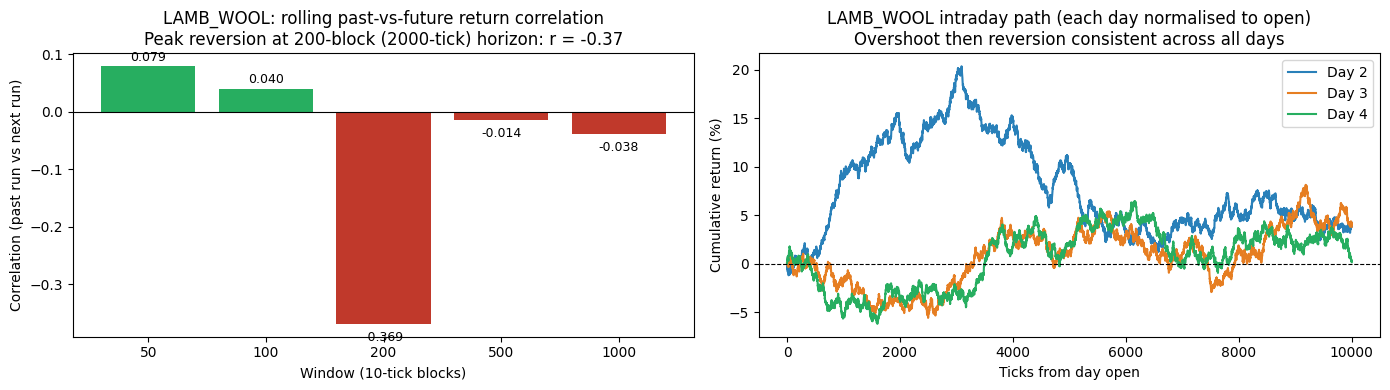

Rolling past-vs-future correlation by window:
     50 blocks (   500 ticks):  +0.0789  +███
    100 blocks (  1000 ticks):  +0.0396  +█
    200 blocks (  2000 ticks):  -0.3686  -██████████████
    500 blocks (  5000 ticks):  -0.0137  -
   1000 blocks ( 10000 ticks):  -0.0380  -█

The -0.37 correlation at the 200-block / 2000-tick horizon is the structural signal:
LAMB_WOOL runs hard in one direction, then corrects an equivalent amount.
This repeats across all three days and is not confined to a single intraday regime.



In [42]:

# ── LAMB_WOOL mean reversion: whole-market rolling correlation ─────────────────
LAMB = "SLEEP_POD_LAMB_WOOL"
lw   = returns[LAMB].values

windows = [50, 100, 200, 500, 1000]
corrs   = []
for w in windows:
    s      = pd.Series(lw)
    past   = s.rolling(w).sum().iloc[w:-w].values
    future = s.rolling(w).sum().shift(-w).iloc[w:-w].values
    n = min(len(past), len(future))
    c = np.corrcoef(past[:n], future[:n])[0, 1]
    corrs.append(c)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: rolling past-vs-future correlation at different horizons
axes[0].bar([str(w) for w in windows], corrs, color=["#c0392b" if c < 0 else "#27ae60" for c in corrs])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Window (10-tick blocks)")
axes[0].set_ylabel("Correlation (past run vs next run)")
axes[0].set_title("LAMB_WOOL: rolling past-vs-future return correlation\n"
                  "Peak reversion at 200-block (2000-tick) horizon: r = -0.37")
for i, (w, c) in enumerate(zip(windows, corrs)):
    axes[0].text(i, c + (0.01 if c >= 0 else -0.03), f"{c:.3f}", ha="center", fontsize=9)

# Right: normalised price path per day for LAMB_WOOL
mids_raw = prices.pivot_table(index="timestamp", columns="product", values="mid_price").sort_index().ffill()
colors = ["#2980b9", "#e67e22", "#27ae60"]
for d, (lo, hi), col in zip([2, 3, 4], DAY_BOUNDS, colors):
    day  = mids_raw[(mids_raw.index >= lo) & (mids_raw.index < hi)]
    norm = (day[LAMB] / day[LAMB].iloc[0] - 1) * 100
    axes[1].plot((day.index - lo) / 100, norm, label=f"Day {d}", color=col)

axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Ticks from day open")
axes[1].set_ylabel("Cumulative return (%)")
axes[1].set_title("LAMB_WOOL intraday path (each day normalised to open)\n"
                  "Overshoot then reversion consistent across all days")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Rolling past-vs-future correlation by window:")
for w, c in zip(windows, corrs):
    bar = "█" * int(abs(c) * 40)
    sign = "-" if c < 0 else "+"
    print(f"  {w:5d} blocks ({w*10:6d} ticks):  {c:+.4f}  {sign}{bar}")

print("""
The -0.37 correlation at the 200-block / 2000-tick horizon is the structural signal:
LAMB_WOOL runs hard in one direction, then corrects an equivalent amount.
This repeats across all three days and is not confined to a single intraday regime.
""")


In [45]:

# ── Backtester setup ──────────────────────────────────────────────────────────
import sys
import json as _json
from collections import defaultdict

sys.path.insert(0, '..')
from datamodel import TradingState, Listing, OrderDepth, Trade, Order, Observation


class Backtester:
    def __init__(self, trader, listings, position_limit, fair_marks, market_data, trade_history):
        self.trader         = trader
        self.listings       = listings
        self.market_data    = market_data.copy()
        self.position_limit = position_limit
        self.fair_marks     = fair_marks
        self.trade_history  = trade_history.sort_values(by=['timestamp', 'symbol'])
        self.observations   = [Observation({}, {}) for _ in range(len(market_data))]
        self.current_position = {p: 0 for p in listings}
        self.pnl_history    = []
        self.pnl            = {p: 0 for p in listings}
        self.cash           = {p: 0 for p in listings}

    def run(self):
        traderData    = ''
        ts_md         = self.market_data.groupby('timestamp')
        ts_th         = self.trade_history.groupby('timestamp')
        own_trades    = defaultdict(list)
        market_trades = defaultdict(list)

        trade_hist_dict = {}
        for ts, grp in ts_th:
            trade_hist_dict[ts] = [
                Trade(row['symbol'], int(row['price']), int(row['quantity']),
                      row['buyer'] if pd.notnull(row.get('buyer', '')) else '',
                      row['seller'] if pd.notnull(row.get('seller', '')) else '', ts)
                for _, row in grp.iterrows()
            ]

        for ts, grp in ts_md:
            od_trade = self._build_od(grp)
            od_pnl   = self._build_od(grp)
            state    = TradingState(traderData, ts, self.listings, od_trade,
                                    dict(own_trades), dict(market_trades),
                                    self.current_position, self.observations[0])
            orders, _, traderData = self.trader.run(state)

            products = grp['product'].tolist()
            for prod in products:
                new_trades = []
                for order in orders.get(prod, []):
                    done, _ = self._execute(ts, order, od_trade, self.current_position,
                                            self.cash, trade_hist_dict, '')
                    new_trades.extend(done)
                if new_trades:
                    own_trades[prod] = new_trades

            t_at_ts = trade_hist_dict.get(ts, [])
            if t_at_ts:
                for t in t_at_ts:
                    market_trades[t.symbol].append(t)
            else:
                for prod in products:
                    market_trades[prod] = []

            for prod in products:
                self._mark(od_pnl, prod)
                self.pnl_history.append(self.pnl[prod])

        return self.pnl

    def _build_od(self, grp):
        od_map = {}
        for _, row in grp.iterrows():
            prod = row['product']
            od   = OrderDepth()
            for i in range(1, 4):
                bp, bv = row.get(f'bid_price_{i}'), row.get(f'bid_volume_{i}')
                ap, av = row.get(f'ask_price_{i}'), row.get(f'ask_volume_{i}')
                if pd.notna(bp) and pd.notna(bv) and str(bp) != '' and str(bv) != '':
                    od.buy_orders[int(float(bp))]  =  int(float(bv))
                if pd.notna(ap) and pd.notna(av) and str(ap) != '' and str(av) != '':
                    od.sell_orders[int(float(ap))] = -int(float(av))
            od_map[prod] = od
        return od_map

    def _mark(self, od_map, prod):
        od = od_map.get(prod)
        if od is None or not od.buy_orders or not od.sell_orders:
            return
        mid = (max(od.buy_orders) + min(od.sell_orders)) / 2.0
        fair = self.fair_marks[prod](od) if prod in self.fair_marks else mid
        self.pnl[prod] = self.cash[prod] + fair * self.current_position[prod]

    def _execute(self, ts, order, od_map, pos, cash, hist, log):
        if order.quantity == 0:
            return [], log
        return self._buy(ts, order, od_map, pos, cash, hist, log) if order.quantity > 0 \
               else self._sell(ts, order, od_map, pos, cash, hist, log)

    def _buy(self, ts, order, od_map, pos, cash, hist, log):
        trades, od = [], od_map[order.symbol]
        for price in sorted(od.sell_orders):
            if price > order.price or order.quantity == 0:
                break
            vol = min(order.quantity, abs(od.sell_orders[price]),
                      int(self.position_limit[order.symbol]) - pos[order.symbol])
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, 'SUBMISSION', '', ts))
                pos[order.symbol] += vol; cash[order.symbol] -= price * vol
                od.sell_orders[price] += vol; order.quantity -= vol
            if od.sell_orders.get(price) == 0:
                del od.sell_orders[price]
        for t in hist.get(ts, []):
            if t.symbol == order.symbol and t.price < order.price and order.quantity > 0:
                vol = min(order.quantity, t.quantity)
                trades.append(Trade(order.symbol, order.price, vol, 'SUBMISSION', '', ts))
                pos[order.symbol] += vol; cash[order.symbol] -= order.price * vol
                order.quantity -= vol
        return trades, log

    def _sell(self, ts, order, od_map, pos, cash, hist, log):
        trades, od = [], od_map[order.symbol]
        for price in sorted(od.buy_orders, reverse=True):
            if price < order.price or order.quantity == 0:
                break
            vol = min(abs(order.quantity), od.buy_orders[price],
                      int(self.position_limit[order.symbol]) + pos[order.symbol])
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, '', 'SUBMISSION', ts))
                pos[order.symbol] -= vol; cash[order.symbol] += price * vol
                od.buy_orders[price] -= vol; order.quantity += vol
            if od.buy_orders.get(price) == 0:
                del od.buy_orders[price]
        return trades, log


# ── LAMB_WOOL Reversal Trader ──────────────────────────────────────────────────
class LambWoolReversalTrader:
    LAMB         = "SLEEP_POD_LAMB_WOOL"
    SIGNAL_TICKS = 1500      # observe this many ticks before entering
    THRESHOLD    = 0.01      # minimum early return to trigger signal
    LIMIT        = 10

    def run(self, state: TradingState):
        mem = _json.loads(state.traderData) if state.traderData else {}

        day_ts = state.timestamp % 1_000_000

        # ── detect new day ──
        if day_ts < mem.get('last_day_ts', day_ts):
            mem = {'last_day_ts': day_ts}

        # ── record day-open price ──
        od = state.order_depths.get(self.LAMB)
        mid = None
        if od and od.buy_orders and od.sell_orders:
            mid = (max(od.buy_orders) + min(od.sell_orders)) / 2.0

        if 'open' not in mem and mid is not None:
            mem['open'] = mid

        # ── set signal once after SIGNAL_TICKS ticks ──
        if 'signal' not in mem and day_ts >= self.SIGNAL_TICKS * 100 and mid is not None and 'open' in mem:
            early_ret = (mid - mem['open']) / mem['open']
            if abs(early_ret) >= self.THRESHOLD:
                mem['signal'] = -1 if early_ret > 0 else 1  # -1 = short, +1 = long

        orders: dict = {}

        if 'signal' in mem and od is not None:
            target = mem['signal'] * self.LIMIT
            pos    = state.position.get(self.LAMB, 0)
            needed = target - pos

            if needed > 0 and od.sell_orders:
                best_ask = min(od.sell_orders)
                orders[self.LAMB] = [Order(self.LAMB, best_ask, needed)]
            elif needed < 0 and od.buy_orders:
                best_bid = max(od.buy_orders)
                orders[self.LAMB] = [Order(self.LAMB, best_bid, needed)]

        mem['last_day_ts'] = day_ts
        return orders, 0, _json.dumps(mem)

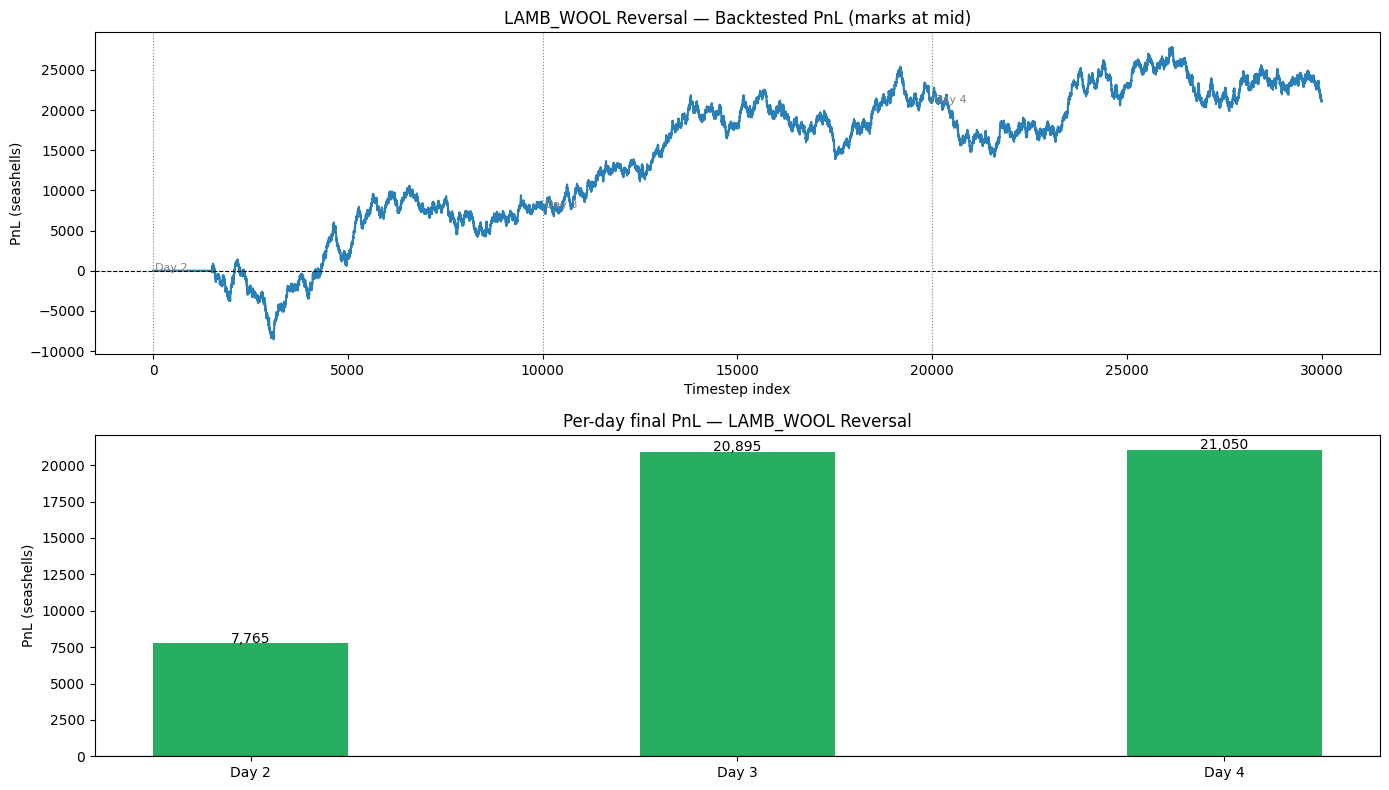


Final PnL summary:
  Day 2: 7,765.0
  Day 3: 20,895.0
  Day 4: 21,050.0
  Total: 49,710.0

Final positions: {'SLEEP_POD_COTTON': 0, 'SLEEP_POD_LAMB_WOOL': 10, 'SLEEP_POD_NYLON': 0, 'SLEEP_POD_POLYESTER': 0, 'SLEEP_POD_SUEDE': 0}


In [46]:
# ── Load trade history for sleep products ─────────────────────────────────────
trade_rows, offset = [], 0
for day in DAYS:
    with open(f'./{BASE}/trades_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

all_trades = pd.DataFrame(trade_rows)
all_trades['timestamp'] = pd.to_numeric(all_trades['timestamp'])
all_trades['price']     = pd.to_numeric(all_trades['price'],    errors='coerce')
all_trades['quantity']  = pd.to_numeric(all_trades['quantity'], errors='coerce')
sleep_trades = all_trades[all_trades['symbol'].str.startswith('SLEEP', na=False)].copy()

# ── Backtest across all days ───────────────────────────────────────────────────
SLEEP_PRODUCTS = [c for c in mids.columns if c.startswith('SLEEP_POD')]
POS_LIMIT      = 10

listings   = {p: Listing(p, p, 'SEASHELLS') for p in SLEEP_PRODUCTS}
pos_lim    = {p: POS_LIMIT for p in SLEEP_PRODUCTS}
fair_marks = {}   # mark at mid price

md_all = prices.copy()                  # full market data (all sleep products)
th_all = sleep_trades.rename(columns={'symbol': 'symbol'}).copy()
if 'buyer'  not in th_all.columns: th_all['buyer']  = ''
if 'seller' not in th_all.columns: th_all['seller'] = ''

trader     = LambWoolReversalTrader()
backtester = Backtester(trader, listings, pos_lim, fair_marks, md_all, th_all)
final_pnl  = backtester.run()

# ── Build per-product PnL series (aligned via market_data rows) ──────────────
md_with_pnl = md_all.copy().reset_index(drop=True)
md_with_pnl['pnl'] = backtester.pnl_history

lamb_pnl_df = md_with_pnl[md_with_pnl['product'] == 'SLEEP_POD_LAMB_WOOL'].copy()
lamb_pnl = lamb_pnl_df.set_index('timestamp')['pnl']

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Top: cumulative LAMB_WOOL PnL across all days
axes[0].plot(lamb_pnl.values, color='#2980b9', linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for d, (lo, hi) in enumerate(DAY_BOUNDS, 2):
    mask = (lamb_pnl.index >= lo) & (lamb_pnl.index < hi)
    if mask.any():
        x_start = np.where(lamb_pnl.index >= lo)[0][0]
        axes[0].axvline(x_start, color='gray', linewidth=0.8, linestyle=':')
        axes[0].text(x_start + 50, lamb_pnl.values[x_start],
                     f'Day {d}', fontsize=8, color='gray')
axes[0].set_title('LAMB_WOOL Reversal — Backtested PnL (marks at mid)')
axes[0].set_ylabel('PnL (seashells)')
axes[0].set_xlabel('Timestep index')

# Bottom: per-day final PnL bar chart
day_pnls = {}
for d, (lo, hi) in enumerate(DAY_BOUNDS, 2):
    mask = (lamb_pnl.index >= lo) & (lamb_pnl.index < hi)
    if mask.any():
        day_pnls[f'Day {d}'] = lamb_pnl[mask].iloc[-1]

colors = ['#27ae60' if v >= 0 else '#c0392b' for v in day_pnls.values()]
axes[1].bar(day_pnls.keys(), day_pnls.values(), color=colors, width=0.4)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, (label, val) in enumerate(day_pnls.items()):
    axes[1].text(i, val + (50 if val >= 0 else -150), f'{val:,.0f}', ha='center', fontsize=10)
axes[1].set_title('Per-day final PnL — LAMB_WOOL Reversal')
axes[1].set_ylabel('PnL (seashells)')

plt.tight_layout()
plt.show()

print("\nFinal PnL summary:")
for label, val in day_pnls.items():
    print(f"  {label}: {val:,.1f}")
print(f"  Total: {sum(day_pnls.values()):,.1f}")
print(f"\nFinal positions: { {p: backtester.current_position[p] for p in SLEEP_PRODUCTS} }")
